In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

CSV_PATH = "/content/drive/MyDrive/G4A/session_funnel.csv"
df = pd.read_csv(CSV_PATH, parse_dates=["session_date"])
df.head()

,user_pseudo_id,session_id,session_date,device_category,country,traffic_source,traffic_medium,viewed,cart,checkout,purchased,revenue
0,4.931932e+07,2558084815,2020-11-01,desktop,Canada,(data deleted),(data deleted),0,0,0,0,0
1,5.528215e+07,5519158838,2020-11-01,mobile,United States,(data deleted),(data deleted),0,0,0,0,0
2,3.130896e+06,7380639657,2020-11-01,desktop,United States,(data deleted),(data deleted),0,0,0,0,0
3,6.499984e+07,3384822736,2020-11-01,mobile,United Kingdom,(data deleted),(data deleted),0,0,0,0,0
4,1.225362e+07,2373337243,2020-11-01,mobile,Singapore,(data deleted),(data deleted),0,0,0,0,0


In [ ]:
funnel_counts = {
    "sessions": len(df),
    "viewed": int(df["viewed"].sum()),
    "cart": int(df["cart"].sum()),
    "checkout": int(df["checkout"].sum()),
    "purchased": int(df["purchased"].sum()),
}

stages = ["sessions", "viewed", "cart", "checkout", "purchased"]
for i in range(len(stages) - 1):
    cur, nxt = stages[i], stages[i + 1]
    rate = 100 * funnel_counts[nxt] / funnel_counts[cur]
    print(f"{cur} -> {nxt}: {rate:.2f}%")

avg_order_value = df.loc[df["purchased"] == 1, "revenue"].sum() / funnel_counts["purchased"]
print(f"\nAverage order value: ${avg_order_value:,.2f}")
print(f"Overall conversion: {100 * funnel_counts['purchased'] / funnel_counts['sessions']:.2f}%")

sessions -> viewed: 21.39%
viewed -> cart: 19.72%
cart -> checkout: 73.12%
checkout -> purchased: 43.65%

Average order value: $74.70
Overall conversion: 1.35%


In [ ]:
def significance_test(df, segment_col, seg_a, seg_b, outcome_col="purchased"):
    sub = df[df[segment_col].isin([seg_a, seg_b])]
    table = pd.crosstab(sub[segment_col], sub[outcome_col])
    chi2, p, dof, expected = chi2_contingency(table)
    return chi2, p, table

chi2, p, table = significance_test(df, "device_category", "mobile", "desktop")
print(table)
print(f"\nchi2 = {chi2:.2f}, p-value = {p:.4f}")
if p < 0.05:
    print("Statistically significant difference in conversion rate (p < 0.05).")
else:
    print("Not statistically significant at the 5% level — treat the gap as noise until more data says otherwise.")

purchased             0     1
device_category              
desktop          206193  2749
mobile           141190  1995

chi2 = 3.79, p-value = 0.0514
Not statistically significant at the 5% level — treat the gap as noise until more data says otherwise.


In [ ]:
def model_funnel_improvement(stage_from, stage_to, improvement_pts, funnel_counts, avg_order_value):
    base_from = funnel_counts[stage_from]
    extra_at_to = base_from * (improvement_pts / 100)

    downstream_rate = 1.0
    idx_to = stages.index(stage_to)
    for i in range(idx_to, len(stages) - 1):
        cur, nxt = stages[i], stages[i + 1]
        downstream_rate *= funnel_counts[nxt] / funnel_counts[cur]

    extra_purchases = extra_at_to * downstream_rate
    extra_revenue = extra_purchases * avg_order_value
    return extra_purchases, extra_revenue

stage_transitions = [
    ("sessions", "viewed", "Session -> View"),
    ("viewed", "cart", "View -> Cart"),
    ("cart", "checkout", "Cart -> Checkout"),
    ("checkout", "purchased", "Checkout -> Purchase"),
]

results = []
for stage_from, stage_to, label in stage_transitions:
    for pts in [1, 5, 10]:
        extra_purchases, extra_revenue = model_funnel_improvement(
            stage_from, stage_to, pts, funnel_counts, avg_order_value
        )
        results.append({
            "stage": label,
            "improvement_pts": pts,
            "extra_purchases": round(extra_purchases, 1),
            "extra_revenue": round(extra_revenue, 2),
        })

results_df = pd.DataFrame(results)

num_days = df["session_date"].nunique()
results_df["extra_revenue_per_day"] = (results_df["extra_revenue"] / num_days).round(2)

results_df

,stage,improvement_pts,extra_purchases,extra_revenue,extra_revenue_per_day
0,Session -> View,1,226.7,16934.06,184.07
1,Session -> View,5,1133.4,84670.29,920.33
2,Session -> View,10,2266.8,169340.59,1840.66
3,View -> Cart,1,245.8,18365.78,199.63
4,View -> Cart,5,1229.2,91828.91,998.14
5,View -> Cart,10,2458.5,183657.81,1996.28
6,Cart -> Checkout,1,66.3,4952.78,53.83
7,Cart -> Checkout,5,331.5,24763.92,269.17
8,Cart -> Checkout,10,663.0,49527.84,538.35
9,Checkout -> Purchase,1,111.1,8296.63,90.18


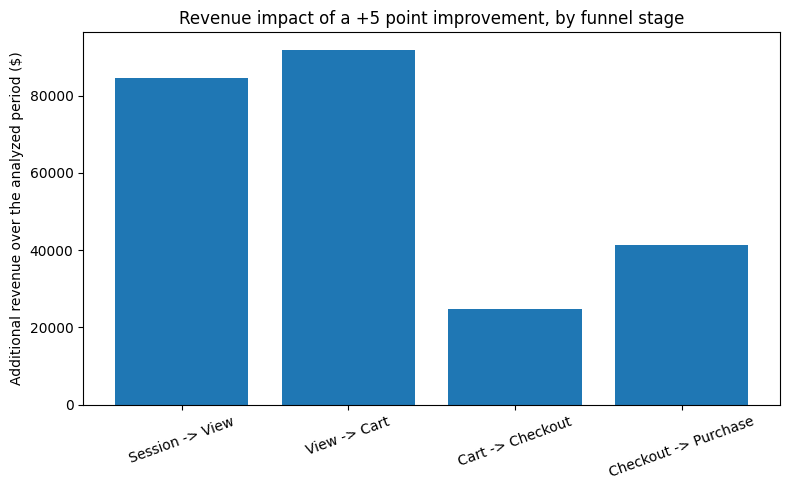

In [ ]:
plot_df = results_df[results_df["improvement_pts"] == 5]

plt.figure(figsize=(8, 5))
plt.bar(plot_df["stage"], plot_df["extra_revenue"])
plt.ylabel("Additional revenue over the analyzed period ($)")
plt.title("Revenue impact of a +5 point improvement, by funnel stage")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()